In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import norm

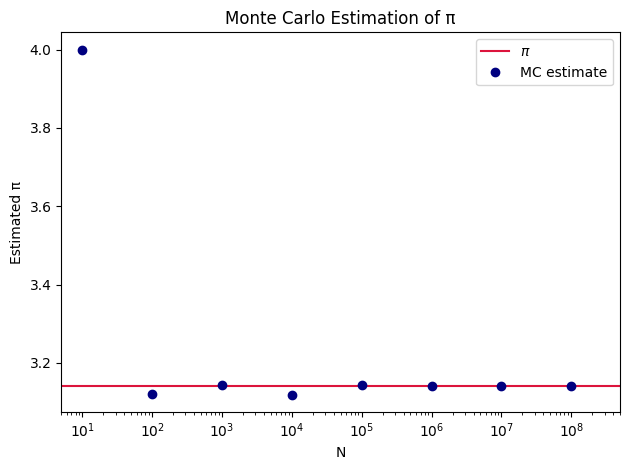

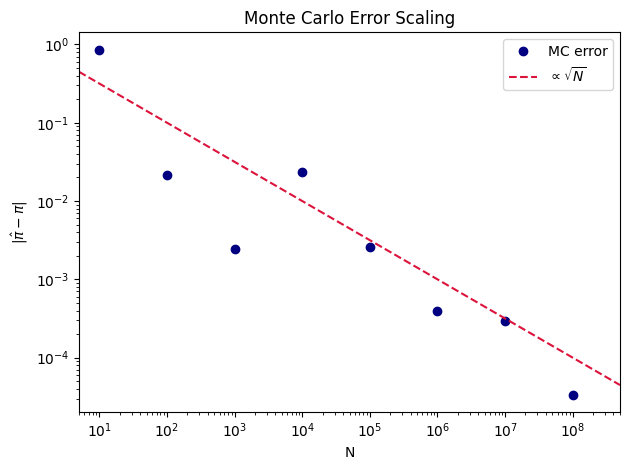

In [2]:
# Total random points
N = int(1e8)

# Generate random points once
x = 2 * (np.random.random(N) - 0.5)
y = 2 * (np.random.random(N) - 0.5)
r = np.sqrt(x**2 + y**2)

# Iteration sizes
NIts = np.array([10**i for i in range(1, 9)])

# Monte Carlo estimates of pi
pi_estims = []
errors = []

for NIt in NIts:
    N_circ = np.sum(r[:NIt] <= 1)
    pi_est = 4 * N_circ / NIt
    pi_estims.append(pi_est)
    errors.append(np.abs(pi_est - np.pi))

pi_estims = np.array(pi_estims)
errors = np.array(errors)

# -------- Plot 1: Estimate of pi --------
plt.figure()
plt.axhline(np.pi, color="crimson", label=r"$\pi$")
plt.plot(NIts, pi_estims, "o", color="navy", label="MC estimate")
plt.xscale("log")
plt.xlim(5e0, 5e8)
plt.xlabel("N")
plt.ylabel("Estimated π")
plt.title("Monte Carlo Estimation of π")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Plot 2: Error vs N (log-log) --------
plt.figure()
plt.loglog(NIts, errors, "o", color="navy", label="MC error")

# Theoretical scaling ~ N^{-1/2}
N_line = np.logspace(np.log10(5e0), np.log10(5e8), 300)
plt.loglog(N_line, 1 / np.sqrt(N_line), "--", color="crimson", label=r"$\propto \sqrt{N}$")

plt.xlim(5e0, 5e8)
plt.xlabel("N")
plt.ylabel(r"$|\hat{\pi} - \pi|$")
plt.title("Monte Carlo Error Scaling")
plt.legend()
plt.tight_layout()
plt.show()


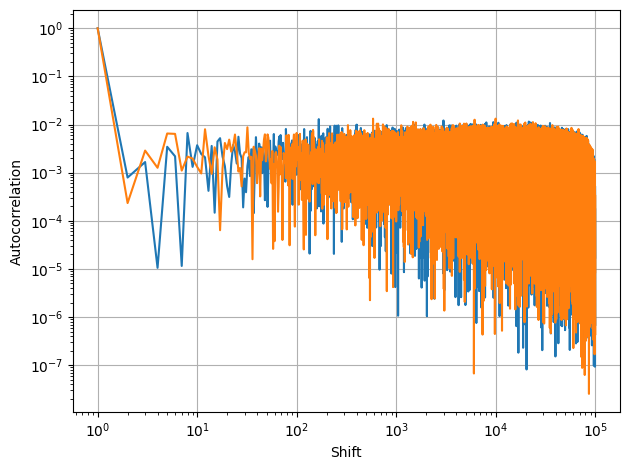

In [3]:
#LCG generator
def lcg_random(N, seed=12345):
    """
    Generate N random floats in [0,1) using a simple LCG.
    Plain Python, no NumPy.
    """
    a = 1103515245   # multiplier
    c = 12345        # increment
    m = 2**31        # modulus
    state = seed

    result = []
    for _ in range(N):
        state = (a * state + c) % m
        result.append(state / m)
    return np.array(result)
    
N=int(1e5)

#random numbers
r_np = 2*(np.random.random(N)-0.5)
r_LCG = 2*(lcg_random(N)-0.5)

#Autocorrelation
ac_np = np.correlate(r_np, r_np, mode='full')  # full correlation
ac_np = ac_np[ac_np.size // 2:]  
ac_np /= ac_np[0]

ac_LCG = np.correlate(r_LCG, r_LCG, mode='full')  # full correlation
ac_LCG = ac_LCG[ac_LCG.size // 2:]  
ac_LCG /= ac_LCG[0]

plt.figure()
plt.plot(np.array(range(N))+1,np.abs(ac_np[:]))
plt.plot(np.array(range(N))+1,np.abs(ac_LCG[:]))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Shift")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.tight_layout()
plt.show()

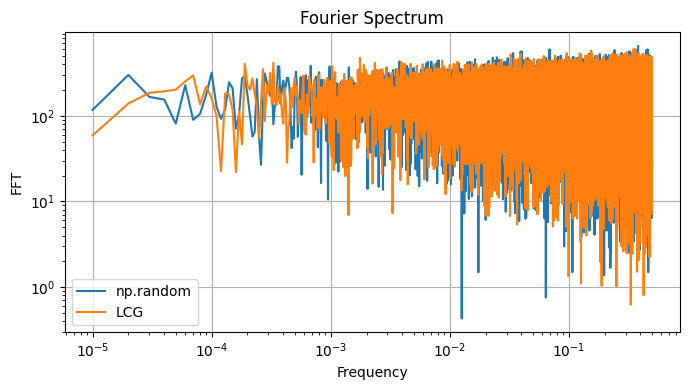

In [4]:
# NumPy FFT for r_np
fft_np = np.fft.rfft(r_np - np.mean(r_np))
power_np = np.abs(fft_np)
freqs_np = np.fft.rfftfreq(N, d=1)

# NumPy FFT for r_LCG
fft_LCG = np.fft.rfft(r_LCG - np.mean(r_LCG))
power_LCG = np.abs(fft_LCG)
freqs_LCG = np.fft.rfftfreq(N, d=1)

# Plot Fourier spectra
plt.figure(figsize=(7,4))
plt.loglog(freqs_np[1:], power_np[1:], label="np.random")  # skip DC
plt.loglog(freqs_LCG[1:], power_LCG[1:], label="LCG")      # skip DC
plt.xlabel("Frequency")
plt.ylabel("FFT")
plt.title("Fourier Spectrum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

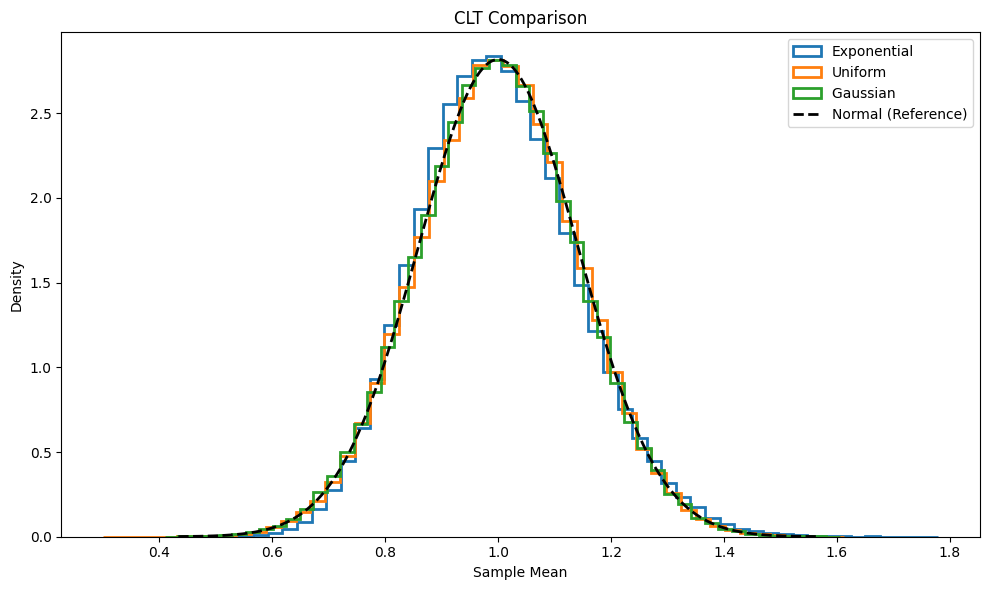

In [5]:
np.random.seed(42)

# Parameters
population_size = 200000
sample_size = 50
num_samples = 200000

# Define different populations with SAME expectation = 1
"""
populations = {
    "Exponential": np.random.exponential(scale=1.0, size=population_size),        
    "Uniform": np.random.uniform(low=0, high=2, size=population_size),           
    "Gaussian ": np.random.normal(1,3, size=population_size),                
}
"""
populations = {
    "Exponential": np.random.exponential(scale=1.0, size=population_size),        
    "Uniform": np.random.uniform(low=1-np.sqrt(3), high=1+np.sqrt(3), size=population_size),           
    "Gaussian ": np.random.normal(1,1, size=population_size),                
}
plt.figure(figsize=(10, 6))

# Collect sample means and plot
for name, population in populations.items():
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(population, size=sample_size, replace=True)
        means.append(np.mean(sample))

    plt.hist(
        means,
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label=name
    )

# Overlay theoretical normal distribution for reference
mu = 1.0  # all expectations = 1

# Estimate variance from one population (or average across them)
all_means = np.concatenate([
    [np.mean(np.random.choice(pop, size=sample_size, replace=True)) for _ in range(2000)]
    for pop in populations.values()
])
sigma = np.std(all_means)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
plt.plot(x, norm.pdf(x, mu, sigma), "k--", linewidth=2, label="Normal (Reference)")

plt.title(f"CLT Comparison")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()